# Day 08. Exercise 00
# Binary classifier. Logistic regression

## 0. Imports

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Preprocessing

- Get the data from the file [`checker-timestamp.csv`](https://drive.google.com/file/d/1pooM4cITtG249msX3GK_6W0eEiblzAf5/view?usp=sharing).


- Create a dataframe `df` with the columns: `date`, `am`, `pm`, `target`, where `date` is the date of the day, `am` is the number of the commits during the day before midday (integer), `pm` is the number of commits during the day after midday (integer), `target` is weekend/working_day.

In [11]:
df = pd.read_csv('../data/checker_timestamp.csv', parse_dates=['timestamp'])
df

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


Выделим из данных нужные нам значения. Время разделим на категории - до полудня и после, а день определим как выходной или будний.

In [12]:
df['date'] = df['timestamp'].dt.date
df['am'] = df['timestamp'].dt.hour.apply(lambda x: 1 if x < 12 else 0)
df['pm'] = df['timestamp'].dt.hour.apply(lambda x: 1 if x >= 12 else 0)
df['target'] = df['timestamp'].dt.dayofweek.apply(lambda x: 'working_day' if x < 5 else 'weekend')
df

,timestamp,date,am,pm,target
0,2020-04-17 05:19:02.744528,2020-04-17,1,0,working_day
1,2020-04-17 05:22:35.249331,2020-04-17,1,0,working_day
2,2020-04-17 05:22:45.549397,2020-04-17,1,0,working_day
3,2020-04-17 05:34:14.691200,2020-04-17,1,0,working_day
4,2020-04-17 05:34:24.422370,2020-04-17,1,0,working_day
...,...,...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,0,1,working_day
3203,2020-05-21 20:22:41.785725,2020-05-21,0,1,working_day
3204,2020-05-21 20:22:41.877806,2020-05-21,0,1,working_day
3205,2020-05-21 20:37:00.129678,2020-05-21,0,1,working_day


## 2. Exploratory analysis

- Create a plot where `x` is am, `y` is pm, each dot is a day, working days and weekends must have different colors.


- By looking at the graph do you think it will be easy to classify the days having those two features? Put your answer in the markdown cell in the end of that sectioin: "yes, it is easy" or "no, it is not easy".

In [13]:
df = df.groupby(['date']).agg({'am': sum, 'pm': sum, 'target':'first'})
df

/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_11124/3742909378.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = df.groupby(['date']).agg({'am': sum, 'pm': sum, 'target':'first'})
/var/folders/_d/q8_c5ntn1zsdjh_6zk89_ch40000gn/T/ipykernel_11124/3742909378.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = df.groupby(['date']).agg({'am': sum, 'pm': sum, 'target':'first'})


,am,pm,target
date,,,
2020-04-17,21,2,working_day
2020-04-18,1,68,weekend
2020-04-19,18,15,weekend
2020-04-20,2,23,working_day
2020-04-21,0,25,working_day
2020-04-22,0,28,working_day
2020-04-23,10,33,working_day
2020-04-24,2,14,working_day
2020-04-25,30,74,weekend


Построим график, где по х - количество коммитов до полудня, по у - количество коммитов после полудня, светлый цвет - рабочий день, темный - выходной.

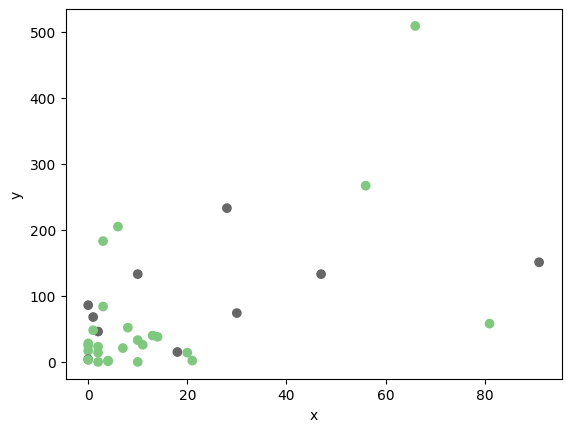

In [14]:
plt.scatter(df['am'], df['pm'], c=[0 if i == 'working_day' else 1 for i in df['target']], cmap='Accent')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 3. Logistic regression

- Train logistic regression on your data using `am` and `pm`, parameters are: `random state=21`, `fit_intercept=False`.


- Make predictions for every day of your dataset and add them to your dataframe with the column name `predict`.


- Save the dataframe into a file in the subfolder of the day `data` with the name `am_pm.csv`.


- Draw another plot like you did before, but the color should be taken from the `predict`.


- By looking at the graph do you think if it made good predictions? Put your answer in the markdown cell in the end of that section: "yes, it is good"; "no, it is not good".

Определим набор признаков для анализа (Х) и целевой признак(у)

In [15]:
X = df[['am', 'pm']].values 
y = df['target'].values

Потренируем регрессию

In [16]:
lr = LogisticRegression(random_state=21, fit_intercept=False)
lr.fit(X, y)
y_pred = lr.predict(X)

Сохраним результаты

In [17]:
df['predict'] = y_pred
df.to_csv('../data/am_pm.csv')

Построим график

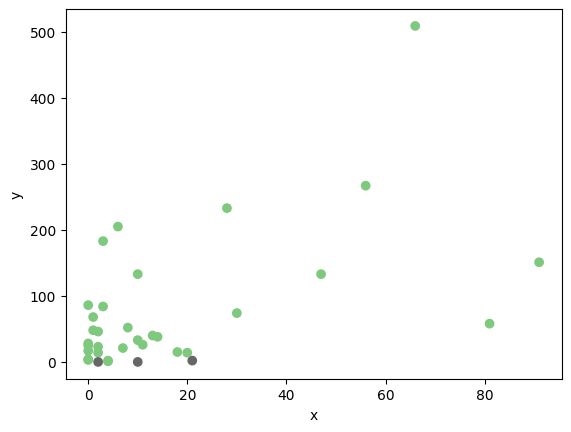

In [18]:
plt.scatter(df['am'], df['pm'], c=[0 if i == 'working_day' else 1 for i in df['predict']], cmap='Accent')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

График показывает, что прогнозы не точны

## 4. Evaluation

- Calculate `accuracy` for your predictions.


- Calculate `accuracy` for the naive case when each of your prediction is the value of your most popular class of the day.


- Comparing the accuracies do you think that the classifier made good predictions? Put your answer in the markdown cell in the end of the secion: "yes, it is good"; "no, it is not good".

Метрики качества

Accuracy определяет долю правильных ответов и считается следующим образом: Accuracy=TP+TN/ TP+TN+FP+FN

Объект имеет характеристику класса 1 и классификатор определяет характеристику как 1. Это означает, что классификатор сработал верно. Величина TP (True positive) содержит общее количество таких ответов. Объект имеет характеристику класса 0, а классификатор определяет характеристику как 1. Это означает, что классификатор сработал не верно. Величина FP (False positive) содержит общее количество таких ответов. Объект имеет характеристику класса 0 и классификатор определяет характеристику как 0. Это означает, что классификатор сработал верно. Величина TN (True negative) содержит общее количество таких ответов. Объект имеет характеристику класса 1, а классификатор определяет характеристику как 0. Это означает, что классификатор сработал не верно. Величина FN (False negative) содержит общее количество таких ответов.

Рассчитаем точность прогнозов

Для случая, когда мы опирались на разделению по признаку до полудня и после

In [19]:
accuracy_score(y, y_pred)

0.6285714285714286

Для случая, когда предсказание является значением самого популярного класса за день. В нашем случае это значит, что все дни определяются как рабочие

In [20]:
accuracy_score(y, [df['target'].mode().values] * len(y))

0.7142857142857143

Сравнивая точность, видим, что классификатор сделал плохие прогнозы